In [1]:
SHAPE = (1, 100, 100)

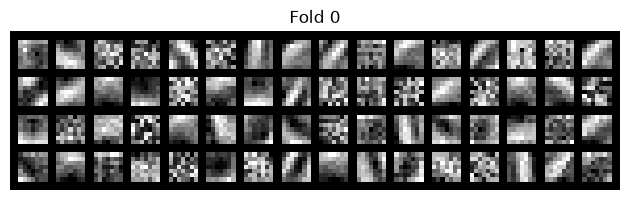

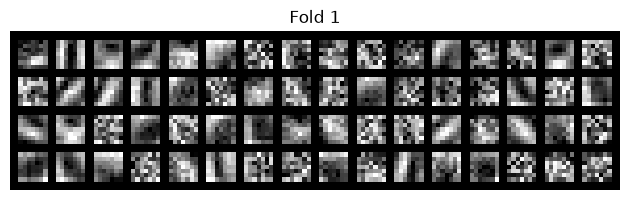

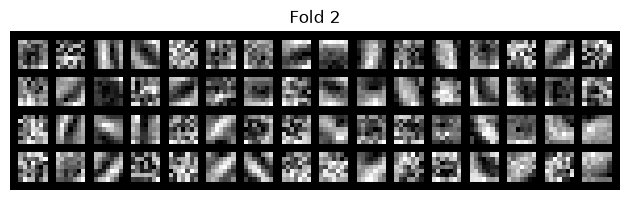

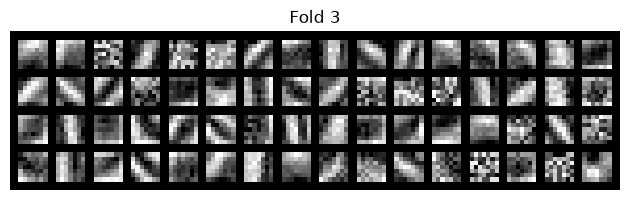

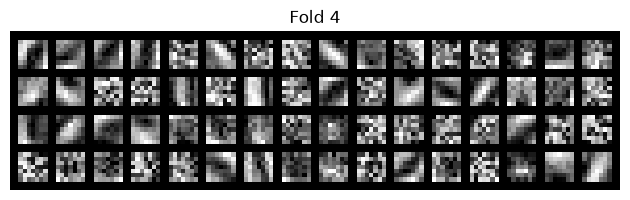

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch as tc
import torchvision

from models import ConvNet


def plot_conv_filters(ax: plt.Axes, tensor: tc.Tensor):
    # see https://stackoverflow.com/questions/55594969/how-to-visualise-filters-in-a-cnn-with-pytorch
    assert tensor is not None

    n, c, w, h = tensor.shape
    tensor = tensor.reshape(n * c, -1, w, h)
    nrow = 16  # math.floor(math.sqrt(tensor.shape[0]))
    grid = torchvision.utils.make_grid(
        tensor, nrow=nrow, normalize=True, scale_each=True
    )
    ax.imshow(grid.numpy().transpose((1, 2, 0)))
    ax.axis("off")


model = ConvNet(shape=SHAPE)
for fold in range(5):
    convnet_checkpoint_path = Path("weights/", f"convnet_fold{fold}_best.pt")
    model.load_state_dict(tc.load(convnet_checkpoint_path))

    # fig, axs = plt.subplots(ncols=3)
    # plot weights of convolutional layers
    # layers = [model.conv0, model.conv1, model.conv2]
    # for ax, layer in zip(axs, layers):
    #     ax.set_title(layer._get_name())
    #     plot_conv_filters(ax, layer.weight)

    fig, ax = plt.subplots()
    ax.set_title(f"Fold {fold}")
    plot_conv_filters(ax, model.conv0.weight)
    fig.set_tight_layout(True)

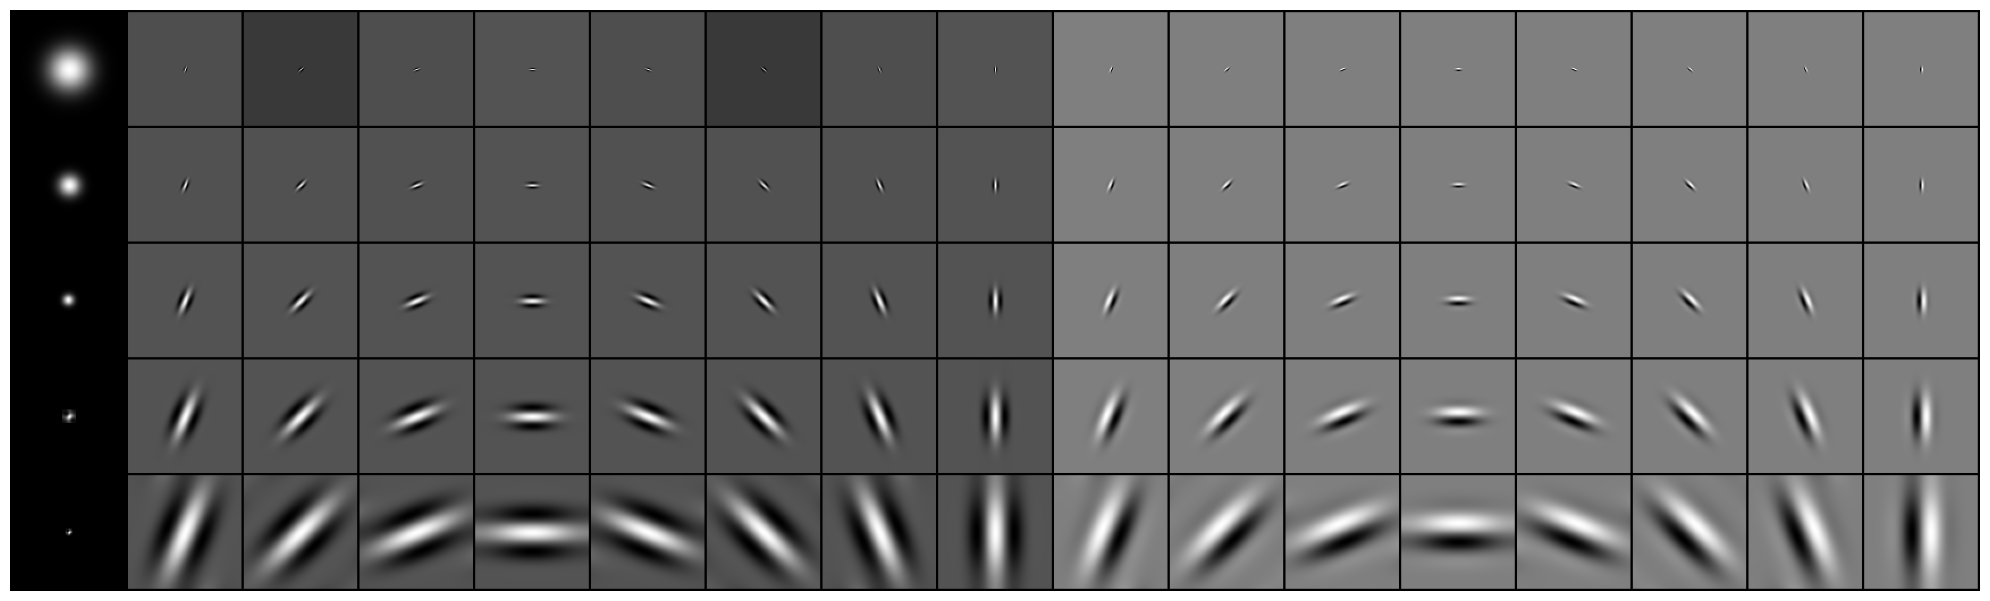

In [5]:
import colorsys
from typing import Final
from pathlib import Path

import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt
from kymatio.scattering2d.filter_bank import filter_bank

from models import ScatNet


def colorize2(z: npt.NDArray[np.complex128]):
    magni = np.abs(z)
    phase = np.angle(z)

    h = (phase + np.pi) / (2 * np.pi) + 0.5
    l = 1.0 / (1.0 + magni**0.3)
    s = 0.8

    c = np.vectorize(colorsys.hls_to_rgb)(h, l, s)  # --> tuple
    print("shape:", c)
    c = np.array(c)  # -->  array of (3,n,m) shape, but need (n,m,3)
    print("shape:", c.shape)
    c = c.squeeze().transpose(1, 2, 0)
    return c


def colorize(z: npt.NDArray[np.complex128]):
    r = np.abs(z)
    arg = np.angle(z)

    h = (arg + np.pi) / (2 * np.pi) + 0.5
    l = 1.0 - 1.0 / (1.0 + r**0.3)
    s = 0.8

    c = np.vectorize(colorsys.hls_to_rgb)(h, l, s)  # --> tuple
    c = np.array(c)  # -->  array of (3,n,m) shape, but need (n,m,3)
    c = c.squeeze().transpose(1, 2, 0)
    return c


def plot_scaling_functions(fig: plt.Figure, filters: dict):
    assert filters is not None

    scales = filters["j"]
    # fig.suptitle(f"Scaling functions for scales $j$")
    axes = fig.subplots(nrows=scales, ncols=1)
    for scale in range(scales):
        ft = filters["levels"][scale]
        fw = np.fft.fftshift(np.fft.fft2(ft))

        ax0 = axes[scale]
        ax0.imshow(fw.real, cmap="gray")
        # ax0.set_title(f"$j$ = {scale}")
        ax0.axis("off")

        # ax1 = axes[scale][1]
        # ax1.imshow(fw.imag, cmap="gray")
        # ax1.set_title(f"$j$ = {scale}")
        # ax1.axis('off')


def plot_wavelet_functions(fig0: plt.Figure, fig1: plt.Figure, filters: list[dict]):
    assert filters is not None

    # count J and K over all filters metadata
    scales = len(set([f["j"] for f in filters]))
    angles = len(set([f["theta"] for f in filters]))
    assert len(filters) == (scales * angles)

    axs0 = fig0.subplots(nrows=scales, ncols=angles)
    # fig0.suptitle(R"Wavelets ($R$) for each scale $j$ and angle $\theta$")

    axs1 = fig1.subplots(nrows=scales, ncols=angles)
    # fig1.suptitle(R"Wavelets ($I$) for each scale $j$ and angle $\theta$")

    for filter in filters:
        # print("filter[0]", filter['levels'][0].shape)
        scale: int = filter["j"]
        angle: int = filter["theta"]
        ft = filter["levels"][0]
        fw = np.fft.fftshift(np.fft.fft2(ft))

        ax0 = axs0[scale][angle]
        ax0.axis("off")
        ax0.imshow(fw.real, cmap="gray")  # , aspect='auto')
        # ax0.set_title(f"$j = {scale}$ \n $\\theta={angle}$")

        ax1 = axs1[scale][angle]
        ax1.axis("off")
        ax1.imshow(fw.imag, cmap="gray")  # , aspect='auto')
        # ax1.set_title(f"$j = {scale}$ \n $\\theta={angle}$")


def plot_s_func(ax: plt.Axes, filters: list[dict]):
    assert len(filters) > 0

    scales = filters["j"]
    fs = []
    for scale in range(scales):
        ft = filters["levels"][scale]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.real).squeeze().unsqueeze(0))

    maxsize = fs[0].shape[1:]
    print(maxsize)
    # fs = torch.nn.functional.interpolate(fs, size=maxsize)
    #   fs.append(torch.nn.functional.interpolate(real, scale_factor=2**scale).squeeze(0))
    fs = [
        torchvision.transforms.functional.center_crop(f, output_size=maxsize)
        for f in fs
    ]
    grid = torchvision.utils.make_grid(fs, nrow=1, normalize=True, scale_each=True)
    ax.axis("off")
    ax.imshow(grid.numpy().transpose(1, 2, 0), cmap="gray")


def plot_w_real(ax: plt.Axes, filters: list[dict]):
    assert len(filters) > 0

    fs = []
    for filter in filters:
        ft = filter["levels"][0]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.real).squeeze().unsqueeze(0))

    angles = len(set([f["theta"] for f in filters]))
    grid = torchvision.utils.make_grid(fs, nrow=angles, normalize=True, scale_each=True)
    ax.axis("off")
    ax.imshow(grid.numpy().transpose(1, 2, 0), cmap="gray")


def plot_w_imag(ax: plt.Axes, filters: list[dict]):
    assert len(filters) > 0

    fs = []
    for filter in filters:
        ft = filter["levels"][0]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.imag).squeeze().unsqueeze(0))

    angles = len(set([f["theta"] for f in filters]))
    grid = torchvision.utils.make_grid(fs, nrow=angles, normalize=True, scale_each=True)
    ax.axis("off")
    ax.imshow(grid.numpy().transpose(1, 2, 0), cmap="gray")


def extract_s_func(filters: list[dict]):
    assert len(filters) > 0

    scales = filters["j"]
    fs = []
    for scale in range(scales):
        ft = filters["levels"][scale]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.real).squeeze().unsqueeze(0))

    maxsize = fs[0].shape[1:]
    return [
        torchvision.transforms.functional.center_crop(f, output_size=maxsize)
        for f in fs
    ]


def extract_w_real(filters: list[dict]):
    assert len(filters) > 0

    fs = []
    for filter in filters:
        ft = filter["levels"][0]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.real).squeeze().unsqueeze(0))

    return fs


def extract_w_imag(filters: list[dict]):
    assert len(filters) > 0

    fs = []
    for filter in filters:
        ft = filter["levels"][0]
        fw = np.fft.fftshift(np.fft.fft2(ft))
        # channel x H x W
        fs.append(torch.Tensor(fw.imag).squeeze().unsqueeze(0))

    return fs


plt.rc("text", usetex=True)
plt.rc("font", family="serif")

outdir = Path("images/")

model = ScatNet(shape=SHAPE)
phis, psis = model.features.load_filters()

fb: Final = filter_bank(
    M=model.features.shape[0],
    N=model.features.shape[1],
    J=model.features.J,
    L=model.features.L,
)
phis, psis = fb["phi"], fb["psi"]

# mainfig = plt.figure(layout='tight')
# mainfig.tight_layout(pad=0.1)
# subfigs = mainfig.subfigures(ncols=3, width_ratios=[1, L, L])

# plot_scaling_functions(subfigs[0], phis)
# # subfigs[0].subplots_adjust(wspace=0.1, hspace=0.1)
# # fig0.show()
# # fig0.savefig('report/images/scatnet-scaling-filters.png')

# # f = plt.figure()
# plot_wavelet_functions(subfigs[1], subfigs[2], psis)
# # fig1.show()
# # fig1.savefig('report/images/scatnet-wavelet-filters.png')
# subfigs[1].subplots_adjust(wspace=0, hspace=0)
# #f.set_aspect('equal')
# mainfig.savefig(outdir / 'scatnet-filters.png')

fig, ax = plt.subplots(figsize=(20, 10))
sreal = extract_s_func(phis)
wreal = extract_w_real(psis)
wimag = extract_w_imag(psis)
# print(*[x.shape for x in sreal])
# print(*[x.shape for x in wreal])
# print(*[x.shape for x in wimag])
filters = []
angles = len(set([f["theta"] for f in psis]))
for i in range(len(sreal)):
    filters.append(sreal[i])
    filters.extend(wreal[i * angles : (i + 1) * angles])
    filters.extend(wimag[i * angles : (i + 1) * angles])

grid = torchvision.utils.make_grid(
    filters, nrow=1 + 2 * angles, normalize=True, scale_each=True
)
ax.imshow(grid.numpy().transpose(1, 2, 0), cmap="gray")
# ax.set_title(r"scaling function $\phi$ and wavelet $\Re(\psi)$ and $\Im(\psi)$")
ax.axis("off")
fig.set_tight_layout(True)